In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# Funktion: wählt Aktion epsilon-greedy
def epsilon_greedy_agent(Q, state, epsilon):
    
    z = np.random.random()

    if z < epsilon or np.all(Q[state] == Q[state][0]):
        return np.random.randint(Q.shape[1])

    return np.argmax(Q[state])

In [5]:
# Funktion: aktualisiert Reward, Zustand, alpha und gamma für einen gegebenen Zustand
def update_q(Q, state, action, reward, next_state, alpha, gamma):

    best_next_q = np.max(Q[next_state])

    Q[state, action] = (Q[state, action] + alpha * (reward + gamma * best_next_q - Q[state, action]))

    return Q

In [6]:
# Funktion: Trainingsschleife, die das Spiel spielt
def q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1, max_steps=1000):

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    rewards = []

    for episode in range(episodes):

        state, info = env.reset()
        total_reward = 0

        for step in range(max_steps):

            action = epsilon_greedy_agent(Q, state, epsilon)

            next_state, reward, terminated, truncated, info = env.step(action)

            Q = update_q(Q, state, action, reward, next_state, alpha, gamma)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards

In [ ]:
# Umgebung Frozen Lake mit UI (PopUp)
# Slippery = False
env = gym.make("FrozenLake-v1", render_mode="human", is_slippery=False)

Q, rewards = q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1, max_steps=100)

state, info = env.reset()

for step in range(100):

    action = np.argmax(Q[state])

    state, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        break

env.close()

In [7]:
# Funktion: Evaluierung der erolgreichen Versuche nach Q-Array Policy
# Frozen Lake
def eval_q(env, Q, episodes=200, max_steps=100):

    success_count = 0

    for episode in range(episodes):

        state, info = env.reset()

        for step in range(max_steps):

            action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            state = next_state

            if reward == 1:
                success_count += 1
                break

            if terminated or truncated:
                break

    success_rate = success_count / episodes

    return success_rate

In [9]:
# Optimierung von Gamma
gammas = [0, 0.1, 0.5, 0.9, 1.0]

results = []

for gamma in gammas:

    print(f"Training with gamma = {gamma}")

    env_train = gym.make("FrozenLake-v1", is_slippery=False)

    Q, rewards = q_learning(env_train, episodes=5000, alpha=0.1, gamma=gamma, epsilon=0.1)

    env_train.close()

    env_eval = gym.make("FrozenLake-v1", is_slippery=False)

    success_rate = eval_q(env_eval, Q, episodes=200)

    env_eval.close()

    results.append(success_rate)

    print(f"Gamma: {gamma} -> Success rate: {success_rate:.3f}")

Training with gamma = 0
Gamma: 0 -> Success rate: 0.000
Training with gamma = 0.1
Gamma: 0.1 -> Success rate: 1.000
Training with gamma = 0.5
Gamma: 0.5 -> Success rate: 1.000
Training with gamma = 0.9
Gamma: 0.9 -> Success rate: 1.000
Training with gamma = 1.0
Gamma: 1.0 -> Success rate: 1.000


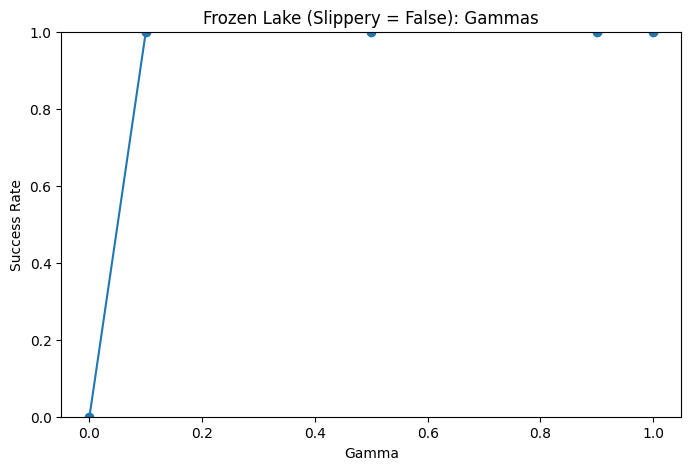

In [12]:
# Plot: Gamma Optimierung mit Slippery = False
plt.figure(figsize=(8,5))

plt.plot(gammas, results, marker='o')

plt.xlabel("Gamma")
plt.ylabel("Success Rate")
plt.title("Frozen Lake (Slippery = False): Gammas")
plt.ylim(0, 1)
plt.show()

In [14]:
# Optimierung von Gamma mit Slippery = True
gammas = [0, 0.1, 0.5, 0.9, 0.99, 1.0]

results = []

for gamma in gammas:

    print(f"Testing gamma = {gamma}")

    run_scores = []

    for run in range(10):

        env_train = gym.make("FrozenLake-v1", is_slippery=True)

        Q, rewards = q_learning(env_train, episodes=5000, alpha=0.1, gamma=gamma, epsilon=0.1)

        env_train.close()

        env_eval = gym.make("FrozenLake-v1", is_slippery=True)

        score = eval_q(env_eval, Q, episodes=200)

        env_eval.close()

        run_scores.append(score)

    mean_score = np.mean(run_scores)

    results.append(mean_score)

    print(f"Gamma {gamma} -> Mean success rate: {mean_score:.3f}")

Testing gamma = 0
Gamma 0 -> Mean success rate: 0.000
Testing gamma = 0.1
Gamma 0.1 -> Mean success rate: 0.051
Testing gamma = 0.5
Gamma 0.5 -> Mean success rate: 0.093
Testing gamma = 0.9
Gamma 0.9 -> Mean success rate: 0.668
Testing gamma = 0.99
Gamma 0.99 -> Mean success rate: 0.708
Testing gamma = 1.0
Gamma 1.0 -> Mean success rate: 0.428


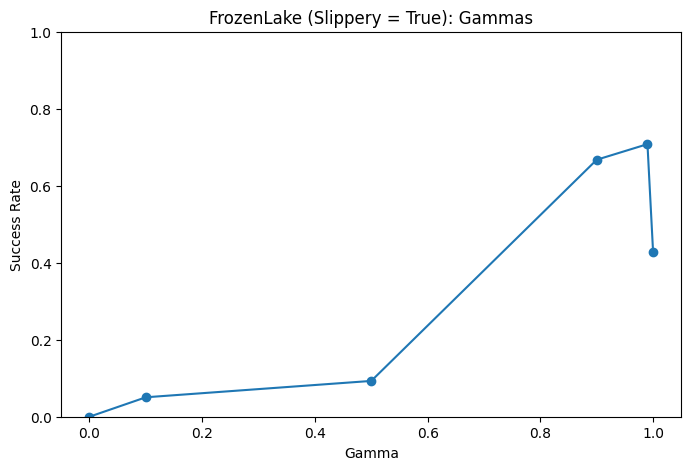

In [16]:
# Plot: Optimierung von Gamma mit Slippery = True
plt.figure(figsize=(8,5))

plt.plot(gammas, results, marker='o')

plt.xlabel("Gamma")
plt.ylabel("Success Rate")
plt.title("FrozenLake (Slippery = True): Gammas")
plt.ylim(0, 1)
plt.show()

In [8]:
# Funktion: Tracking der Lernkurve
def learning_curve(env_name, best_gamma, episodes=5000, eval_interval=50):

    env_train = gym.make(env_name, is_slippery=True)
    env_eval = gym.make(env_name, is_slippery=True)

    n_states = env_train.observation_space.n
    n_actions = env_train.action_space.n

    Q = np.zeros((n_states, n_actions))

    rewards_curve = []
    checkpoints = []

    for episode in range(episodes):

        state, info = env_train.reset()
        total_reward = 0

        for step in range(100):

            action = epsilon_greedy_agent(Q, state, epsilon=0.1)

            next_state, reward, terminated, truncated, info = env_train.step(action)

            Q = update_q(Q, state, action, reward, next_state, alpha=0.1, gamma=best_gamma)

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        if (episode + 1) % eval_interval == 0:

            success_rate = eval_q(env_eval, Q, episodes=100)

            rewards_curve.append(success_rate)
            checkpoints.append(episode + 1)

            print(f"Episode {episode+1}: success rate = {success_rate:.3f}")

    env_train.close()
    env_eval.close()

    return checkpoints, rewards_curve

In [17]:
checkpoints, rewards_curve = learning_curve(
    "FrozenLake-v1",
    best_gamma=0.99,
    episodes=2000,
    eval_interval=50
)

Episode 50: success rate = 0.000
Episode 100: success rate = 0.100
Episode 150: success rate = 0.070
Episode 200: success rate = 0.120
Episode 250: success rate = 0.190
Episode 300: success rate = 0.150
Episode 350: success rate = 0.160
Episode 400: success rate = 0.190
Episode 450: success rate = 0.180
Episode 500: success rate = 0.150
Episode 550: success rate = 0.100
Episode 600: success rate = 0.180
Episode 650: success rate = 0.140
Episode 700: success rate = 0.140
Episode 750: success rate = 0.480
Episode 800: success rate = 0.530
Episode 850: success rate = 0.550
Episode 900: success rate = 0.450
Episode 950: success rate = 0.490
Episode 1000: success rate = 0.610
Episode 1050: success rate = 0.710
Episode 1100: success rate = 0.630
Episode 1150: success rate = 0.620
Episode 1200: success rate = 0.700
Episode 1250: success rate = 0.640
Episode 1300: success rate = 0.630
Episode 1350: success rate = 0.710
Episode 1400: success rate = 0.710
Episode 1450: success rate = 0.620
Episo

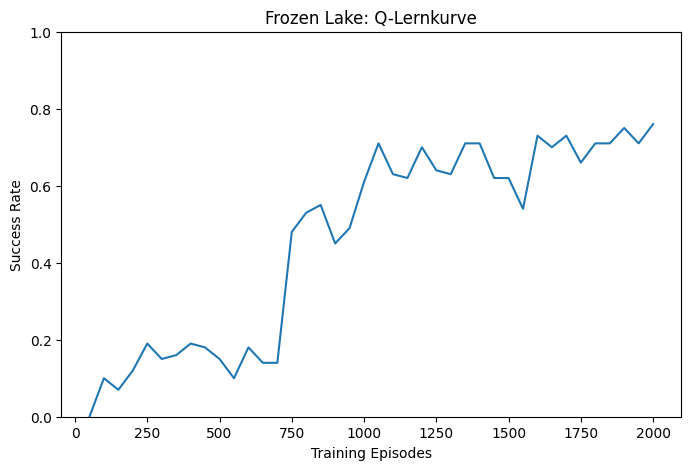

In [18]:
plt.figure(figsize=(8,5))

plt.plot(checkpoints, rewards_curve)

plt.xlabel("Training Episodes")
plt.ylabel("Success Rate")
plt.title("Frozen Lake: Q-Lernkurve")
plt.ylim(0, 1)
plt.show()

In [ ]:
# PopUp UI for Taxi
env = gym.make("Taxi-v4",render_mode="human")
env.metadata["render_fps"] = 30

Q, rewards = q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=0.1, max_steps=1000)

state, info = env.reset()

for step in range(max_steps):

    action = np.argmax(Q[state])

    state, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        break

env.close()

In [26]:
# Evaluierungsfunktion: Taxi
def eval_q_taxi(env, Q, episodes=200, max_steps=200):

    success_count = 0

    for _ in range(episodes):

        state, info = env.reset()

        for _ in range(max_steps):

            action = np.argmax(Q[state])

            state, reward, terminated, truncated, info = env.step(action)

            if terminated:
                
                if reward == 20:
                    success_count += 1

                break

    return success_count / episodes

In [27]:
# Optimierung Gamma: Taxi
gammas = [0, 0.1, 0.5, 0.9, 1.0]

results = []

for gamma in gammas:

    print(f"Training with gamma = {gamma}")

    env_train = gym.make("Taxi-v4")

    Q, rewards = q_learning(env_train, episodes=5000, alpha=0.1, gamma=gamma, epsilon=0.1)

    env_train.close()

    env_eval = gym.make("Taxi-v4")

    success_rate = eval_q_taxi(env_eval, Q, episodes=200)

    env_eval.close()

    results.append(success_rate)

    print(f"Gamma: {gamma} -> Success rate: {success_rate:.3f}")

Training with gamma = 0
Gamma: 0 -> Success rate: 0.000
Training with gamma = 0.1
Gamma: 0.1 -> Success rate: 0.475
Training with gamma = 0.5
Gamma: 0.5 -> Success rate: 0.585
Training with gamma = 0.9
Gamma: 0.9 -> Success rate: 1.000
Training with gamma = 1.0
Gamma: 1.0 -> Success rate: 1.000


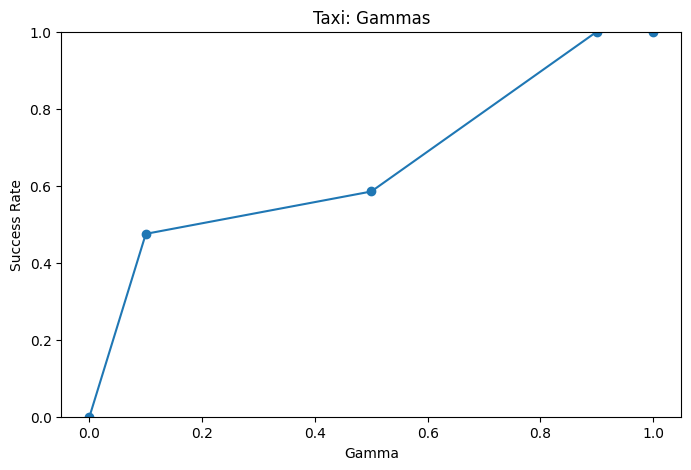

In [28]:
plt.figure(figsize=(8,5))

plt.plot(gammas, results, marker='o')

plt.xlabel("Gamma")
plt.ylabel("Success Rate")
plt.title("Taxi: Gammas")
plt.ylim(0, 1)

plt.show()

In [20]:
# Note: nicht Teil der Aufgabe
# Hyperparameter Optimierung: Epsilon
epsilons = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.9]

results = []

for epsilon in epsilons:

    print(f"Testing epsilon = {epsilon}")

    run_scores = []

    for run in range(10):

        env_train = gym.make("FrozenLake-v1", is_slippery=True)

        Q, rewards = q_learning(env_train, episodes=5000, alpha=0.1, gamma=0.99, epsilon=epsilon)

        env_train.close()

        env_eval = gym.make("FrozenLake-v1", is_slippery=True)

        score = eval_q(env_eval, Q, episodes=200)

        env_eval.close()

        run_scores.append(score)

    mean_score = np.mean(run_scores)

    results.append(mean_score)

    print(f"Epsilon {epsilon} -> Mean success rate: {mean_score:.3f}")

Testing epsilon = 0.0
Epsilon 0.0 -> Mean success rate: 0.040
Testing epsilon = 0.05
Epsilon 0.05 -> Mean success rate: 0.661
Testing epsilon = 0.1
Epsilon 0.1 -> Mean success rate: 0.693
Testing epsilon = 0.2
Epsilon 0.2 -> Mean success rate: 0.722
Testing epsilon = 0.3
Epsilon 0.3 -> Mean success rate: 0.681
Testing epsilon = 0.5
Epsilon 0.5 -> Mean success rate: 0.730
Testing epsilon = 0.9
Epsilon 0.9 -> Mean success rate: 0.698


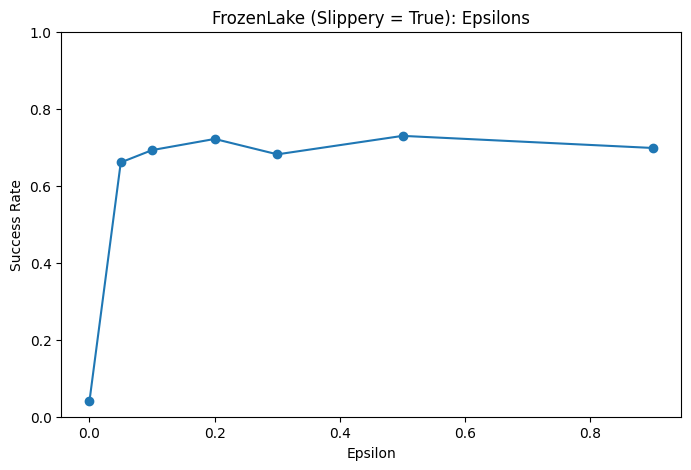

In [21]:
plt.figure(figsize=(8,5))

plt.plot(epsilons, results, marker='o')

plt.xlabel("Epsilon")
plt.ylabel("Success Rate")
plt.title("FrozenLake (Slippery = True): Epsilons")
plt.ylim(0, 1)
plt.show()

In [22]:
# Hyperparameter Optimierung: Alpha
alphas = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]

results = []

for alpha in alphas:

    print(f"Testing alpha = {alpha}")

    run_scores = []

    for run in range(10):

        env_train = gym.make("FrozenLake-v1", is_slippery=True)

        Q, rewards = q_learning(env_train, episodes=5000, alpha= alpha, gamma=0.99, epsilon= 0.1)

        env_train.close()

        env_eval = gym.make("FrozenLake-v1", is_slippery=True)

        score = eval_q(env_eval, Q, episodes=200)

        env_eval.close()

        run_scores.append(score)

    mean_score = np.mean(run_scores)

    results.append(mean_score)

    print(f"Alpha {alpha} -> Mean success rate: {mean_score:.3f}")

Testing alpha = 0.001
Alpha 0.001 -> Mean success rate: 0.083
Testing alpha = 0.01
Alpha 0.01 -> Mean success rate: 0.071
Testing alpha = 0.05
Alpha 0.05 -> Mean success rate: 0.652
Testing alpha = 0.1
Alpha 0.1 -> Mean success rate: 0.736
Testing alpha = 0.2
Alpha 0.2 -> Mean success rate: 0.670
Testing alpha = 0.5
Alpha 0.5 -> Mean success rate: 0.445


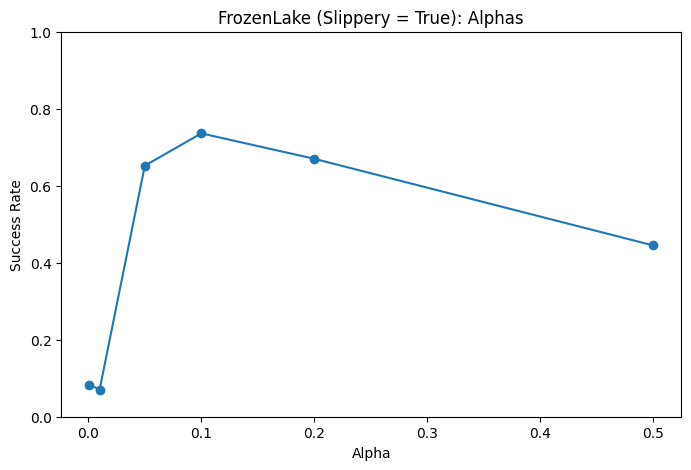

In [24]:
plt.figure(figsize=(8,5))

plt.plot(alphas, results, marker='o')

plt.xlabel("Alpha")
plt.ylabel("Success Rate")
plt.title("FrozenLake (Slippery = True): Alphas")
plt.ylim(0, 1)
plt.show()